=== Variance Telemetry Match ===
Scratch Explained Variance Ratio: [0.92461872 0.05306648]
Sklearn Explained Variance Ratio: [0.92461872 0.05306648]


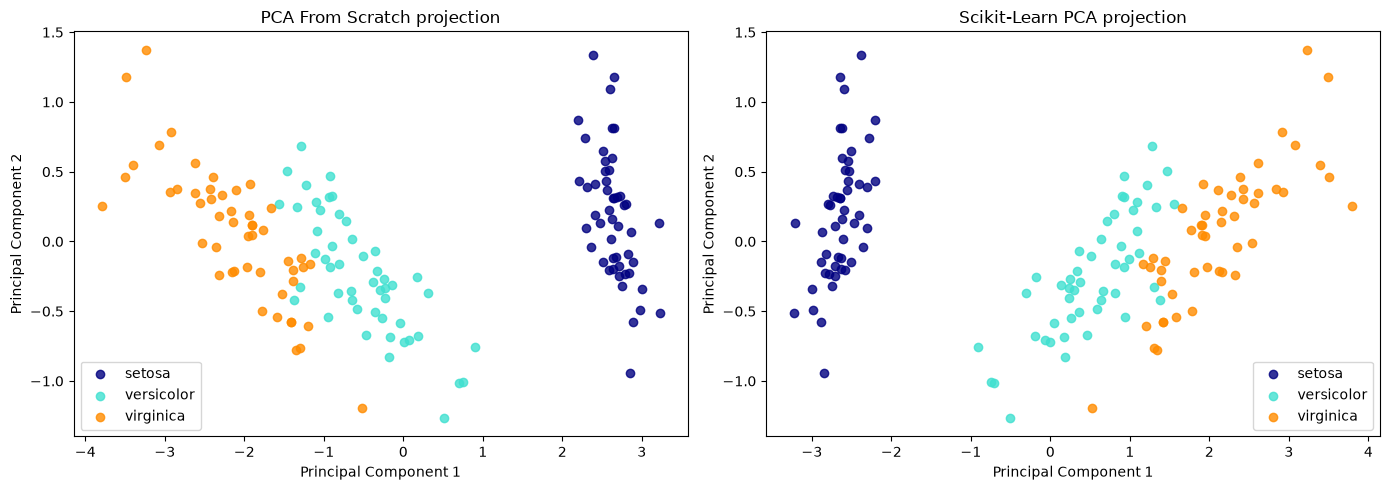

In [4]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load the multi-dimensional Iris dataset (4 Features)
iris = load_iris()
X_raw = iris.data
y_iris = iris.target

class PCAFromScratch:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.mean = None
        self.components = None
        self.eigenvalues = None
        self.explained_variance_ratio_ = None
        
    def fit(self, X):
        # 1. Center the Data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        
        # 2. Calculate Covariance Matrix (shape: n_features x n_features)
        # We divide by N - 1 (unbiased estimator)
        cov_matrix = np.cov(X_centered, rowvar=False)
        
        # 3. Compute Eigenvalues and Eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        
        # Sort in descending order (eigh returns values sorted ascending)
        sorted_idx = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[sorted_idx]
        # Eigenvectors are columns, so we sort the columns
        self.components = eigenvectors[:, sorted_idx]
        
        # Calculate Explained Variance Ratio
        total_variance = np.sum(self.eigenvalues)
        self.explained_variance_ratio_ = (self.eigenvalues / total_variance)[:self.n_components]
        
        # Keep only the requested top d components (projection matrix)
        self.components = self.components[:, :self.n_components]
        
    def transform(self, X):
        # Project centered data onto selected principal component axes
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

# Train Scratch PCA
pca_scratch = PCAFromScratch(n_components=2)
pca_scratch.fit(X_raw)
X_scratch_projected = pca_scratch.transform(X_raw)

# Train Scikit-Learn PCA for comparison
pca_sklearn = PCA(n_components=2, random_state=42)
X_sklearn_projected = pca_sklearn.fit_transform(X_raw)

print("=== Variance Telemetry Match ===")
print("Scratch Explained Variance Ratio:", pca_scratch.explained_variance_ratio_)
print("Sklearn Explained Variance Ratio:", pca_sklearn.explained_variance_ratio_)

# Plot the 2D Projected space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['navy', 'turquoise', 'darkorange']
for idx, color in enumerate(colors):
    ax1.scatter(X_scratch_projected[y_iris == idx, 0], X_scratch_projected[y_iris == idx, 1], 
                color=color, label=iris.target_names[idx], alpha=0.8)
ax1.set_title("PCA From Scratch projection")
ax1.set_xlabel("Principal Component 1")
ax1.set_ylabel("Principal Component 2")
ax1.legend()

# Sklearn eigenvectors can have flipped signs (both are mathematically correct)
# To match exactly, we take the absolute values or adjust plot direction
for idx, color in enumerate(colors):
    ax2.scatter(X_sklearn_projected[y_iris == idx, 0], X_sklearn_projected[y_iris == idx, 1], 
                color=color, label=iris.target_names[idx], alpha=0.8)
ax2.set_title("Scikit-Learn PCA projection")
ax2.set_xlabel("Principal Component 1")
ax2.set_ylabel("Principal Component 2")
ax2.legend()

plt.tight_layout()
plt.show()


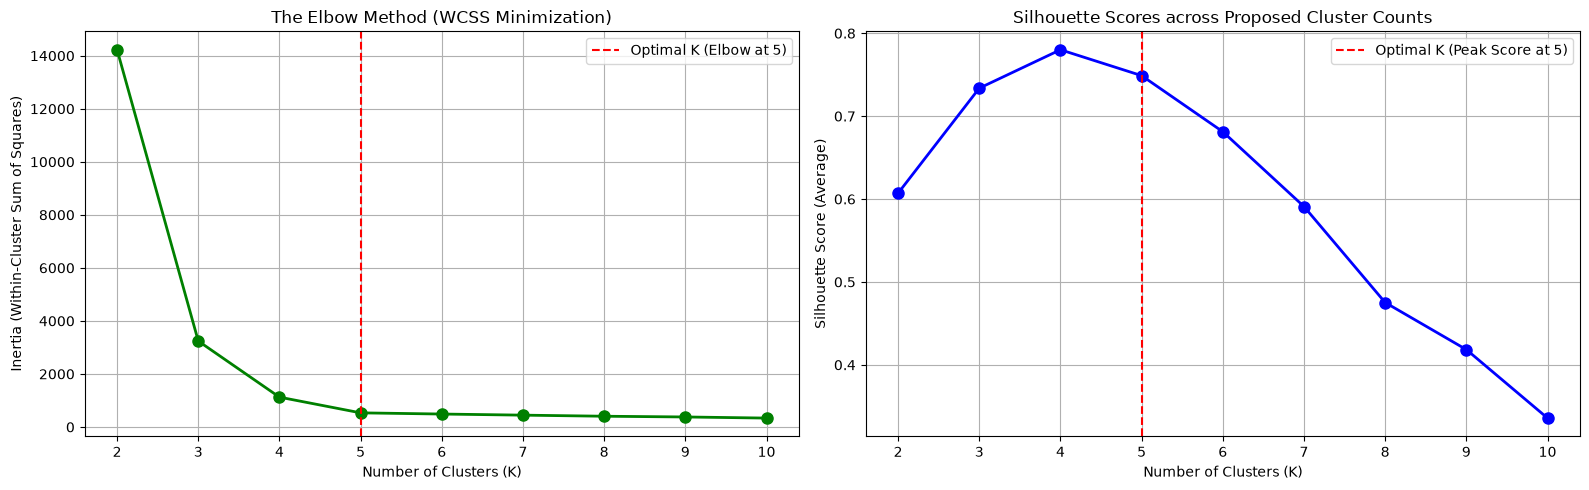

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Generate synthetic cluster dataset with 5 clear coordinate groups
X_clusters, _ = make_blobs(n_samples=500, centers=5, cluster_std=0.75, random_state=42)

# Lists to track metrics over different values of K
k_range = range(2, 11)
inertias = []
silhouette_scores = []

# Execute Loop across proposed cluster spaces
for k in k_range:
    # Initialize and fit model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clusters)
    
    # Track the cluster tightness metric (Inertia)
    inertias.append(kmeans.inertia_)
    
    # Track the cluster separation quality metric (Silhouette Score)
    score = silhouette_score(X_clusters, kmeans.labels_)
    silhouette_scores.append(score)

# Plotting metrics side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: The Elbow Curve using WCSS (Inertia)
ax1.plot(k_range, inertias, 'go-', linewidth=2, markersize=8)
ax1.set_title("The Elbow Method (WCSS Minimization)", fontsize=12)
ax1.set_xlabel("Number of Clusters (K)", fontsize=10)
ax1.set_ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=10)
ax1.grid(True)
# Highlight the elbow with a vertical red dashed line
ax1.axvline(x=5, color='red', linestyle='--', label='Optimal K (Elbow at 5)')
ax1.legend()

# Plot 2: Silhouette Scores (Peak is Best)
ax2.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
ax2.set_title("Silhouette Scores across Proposed Cluster Counts", fontsize=12)
ax2.set_xlabel("Number of Clusters (K)", fontsize=10)
ax2.set_ylabel("Silhouette Score (Average)", fontsize=10)
ax2.grid(True)
# Highlight the peak score
ax2.axvline(x=5, color='red', linestyle='--', label='Optimal K (Peak Score at 5)')
ax2.legend()

plt.tight_layout()
plt.show()
